# Import Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
pip install --upgrade jupyter_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 3.6 MB/s eta 0:00:00
  Attempting uninstall: jupyter_client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
notebook 6.5.7 requires jupyter-client<8,>=5.3.4, but you have jupyter-client 8.8.0 which is incompatible.
jupyter-kernel-gateway 2.5.2 requires jupyter-client<8.0,>=5.2.0, but you have jupyter-client 8.8.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import re
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",


# Load Data  

In [4]:
df = pd.read_csv('/kaggle/input/datasets/retnowardani/southeast-asian-ingredient-pattern-dataset/resep_masakan.csv')

print(df.head())
print(df.info())

      negara           masakan  \
0  Indonesia       Nasi Goreng   
1  Indonesia         Miee Aceh   
2  Indonesia  Tahu Tempe Bacem   
3  Indonesia       Ayam Goreng   
4  Indonesia       Soto Padang   

                                               bahan  
0  nasi, ayam, bawang merah, bawang putih, kecap ...  
1  daging sapi, udang, kaldu, kol, tauge, mie ace...  
2  tahu, tempe, asam, kecap manis, air kelapa par...  
3  ayam, merica, garam, jeruk nipis, asam, lengku...  
4  daging sapi, air, minyak goreng, serai, daun s...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   negara   110 non-null    object
 1   masakan  110 non-null    object
 2   bahan    110 non-null    object
dtypes: object(3)
memory usage: 2.7+ KB
None


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

# Processing Data

## Case folding + remove whitespace + tokenization

In [5]:

df['ingredient_list'] = df['bahan'].apply(
    lambda x: [i.strip().lower() for i in x.split(',')] 
    if isinstance(x, str) else []
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

## Typo correction

In [6]:
correction_dictionary = {
    "miee": "mie",
    "sapig": "sapi",
    "cumie-cumie": "cumi-cumi",
    "dasam": "asam",
    "gar am": "garam"
}

def typo_correction(ingredient_list):
    return [correction_dictionary.get(bahan, bahan) for bahan in ingredient_list]

df['ingredient_list'] = df['ingredient_list'].apply(typo_correction)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

## Synonym normalization

In [7]:
synonym_dictionary = {
    "saus ikan": "kecap ikan",
    "kecap": "kecap manis",
    "bawang": "bawang merah"
}

def ingredient_normalization(ingredient_list):
    result = []
    for bahan in ingredient_list:
        if bahan in synonym_dictionary:
            result.append(synonym_dictionary[bahan])
        else:
            result.append(bahan)
    return list(set(result))

df['ingredient_list'] = df['ingredient_list'].apply(ingredient_normalization)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

## Prepare transactions for Apriori

In [8]:
transaksi = df['ingredient_list'].tolist()
print("Example:", transaksi[0])

Example: ['nasi', 'garam', 'bawang putih', 'kecap manis', 'telur', 'minyak goreng', 'ayam', 'bawang merah']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

## One Hot Encoding

In [9]:
encoder = TransactionEncoder()
result_encoder = encoder.fit(transaksi).transform(transaksi)
data_apriori = pd.DataFrame(result_encoder, columns=encoder.columns_)

print("Jumlah item unik:", len(data_apriori.columns))

Jumlah item unik: 196


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

# Apriori

In [10]:
frequent_itemsets = apriori(data_apriori,min_support=0.15,use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
print("\nTotal Combination:", len(frequent_itemsets))

for i in sorted(frequent_itemsets['length'].unique()):
    print(f"\n=== {i}-itemsets ===")
    display(frequent_itemsets[frequent_itemsets['length'] == i].sort_values(by='support', ascending=False))

frequent_itemsets_display = frequent_itemsets[frequent_itemsets['length'] > 1].sort_values(by='support', ascending=False)


# ASSOCIATION RULES
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

rules = rules[rules['antecedents'].apply(lambda x: len(x) >= 1)]
rules_display = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']] \
                .sort_values(by='confidence', ascending=False)

print("\n=== Associattion Rules ===")
display(rules_display)


Total Combination: 25

=== 1-itemsets ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

,support,itemsets,length
2,0.572727,(bawang putih),1
5,0.554545,(garam),1
6,0.354545,(gula),1
1,0.354545,(bawang merah),1
3,0.309091,(cabai),1
8,0.272727,(minyak goreng),1
0,0.209091,(ayam),1
4,0.181818,(daging sapi),1
9,0.181818,(santan),1
10,0.172727,(telur),1



=== 2-itemsets ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",



=== Associattion Rules ===


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",


,antecedents,consequents,support,confidence,lift
11,"(gula, bawang putih)",(garam),0.218182,0.888889,1.602914
0,(ayam),(bawang putih),0.181818,0.869565,1.518288
8,(gula),(garam),0.300000,0.846154,1.525851
7,(minyak goreng),(bawang putih),0.209091,0.766667,1.338624
1,(ayam),(garam),0.154545,0.739130,1.332858
10,"(gula, garam)",(bawang putih),0.218182,0.727273,1.269841
9,(minyak goreng),(garam),0.190909,0.700000,1.262295
2,(bawang merah),(bawang putih),0.245455,0.692308,1.208791
6,(gula),(bawang putih),0.245455,0.692308,1.208791
3,(cabai),(bawang putih),0.209091,0.676471,1.181139


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

## TOP 15 MOST FREQUENT INGREDIENTS

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

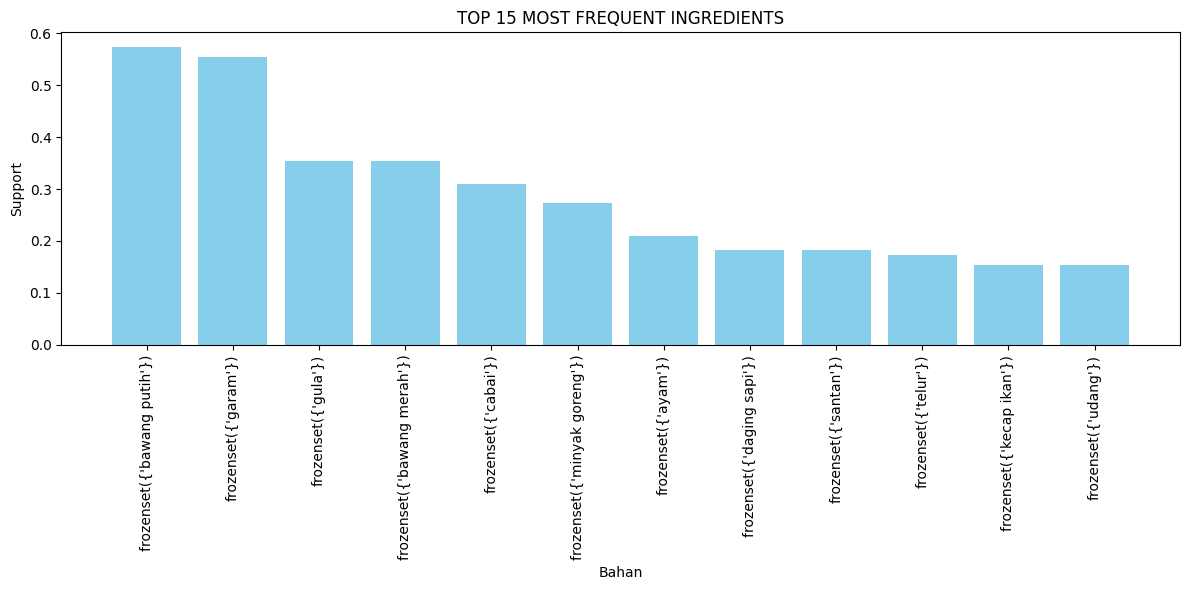

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

In [11]:
support_single = frequent_itemsets[
    frequent_itemsets["itemsets"].apply(lambda x: len(x) == 1)
].sort_values(by="support", ascending=False).head(15)

plt.figure(figsize=(12,6))
plt.bar(
    support_single["itemsets"].astype(str),
    support_single["support"],
    color='skyblue'
)
plt.xticks(rotation=90)
plt.title("TOP 15 MOST FREQUENT INGREDIENTS")
plt.xlabel("Bahan")
plt.ylabel("Support")
plt.tight_layout()
plt.show()

## TOP 10 ASSOCIATION RULES BASED ON CONFIDENCE

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

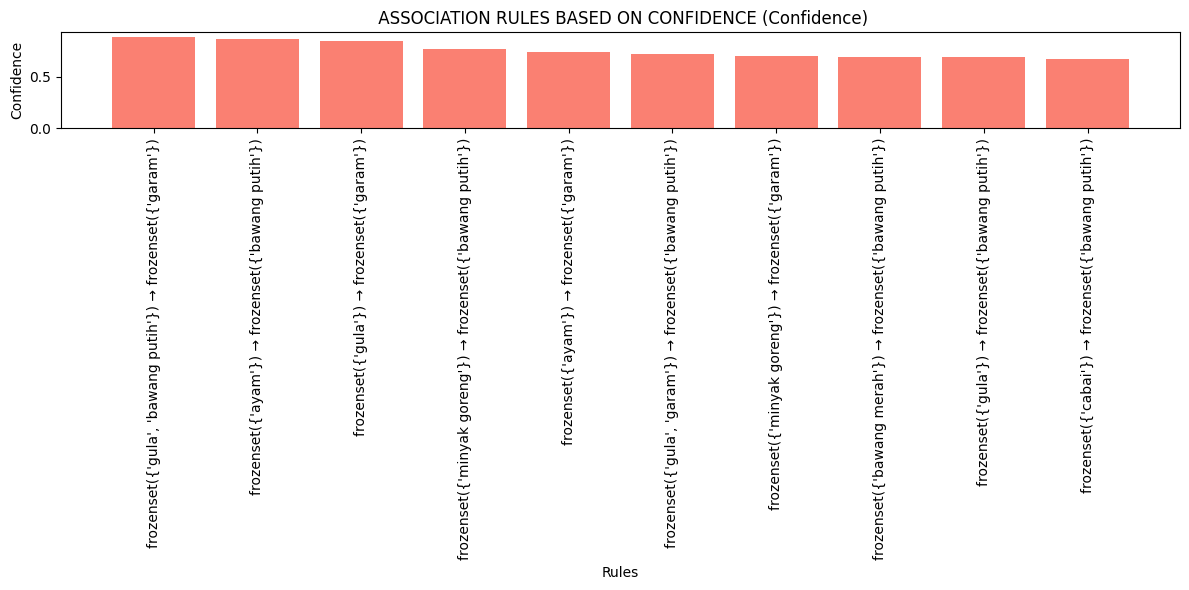

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

In [12]:
if len(rules) > 0:
    rules_sorted = rules.sort_values(by="confidence", ascending=False).head(10)
    
    plt.figure(figsize=(12,6))
    plt.bar(
        rules_sorted["antecedents"].astype(str) + " → " +
        rules_sorted["consequents"].astype(str),
        rules_sorted["confidence"],
        color='salmon'
    )
    plt.xticks(rotation=90)
    plt.title(" ASSOCIATION RULES BASED ON CONFIDENCE (Confidence)")
    plt.xlabel("Rules")
    plt.ylabel("Confidence")
    plt.tight_layout()
    plt.show()
else:
    print("No rules found with the current threshold.")

## Save Model

In [13]:
# Save frequent itemsets
with open('frequent_itemsets.pkl', 'wb') as f:
    pickle.dump(frequent_itemsets, f)

# Save association rules
with open('rules.pkl', 'wb') as f:
    pickle.dump(rules, f)

print("Model (frequent_itemsets & rules) has been saved!")

# Load frequent itemsets
with open('frequent_itemsets.pkl', 'rb') as f:
    frequent_itemsets_loaded = pickle.load(f)

# Load association rules
with open('rules.pkl', 'rb') as f:
    rules_loaded = pickle.load(f)

print("Model has been loaded successfully!")
display(frequent_itemsets_loaded.head(5))
display(rules_loaded.head(5))

Model (frequent_itemsets & rules) has been saved!
Model has been loaded successfully!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

,support,itemsets,length
0,0.209091,(ayam),1
1,0.354545,(bawang merah),1
2,0.572727,(bawang putih),1
3,0.309091,(cabai),1
4,0.181818,(daging sapi),1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(ayam),(bawang putih),0.209091,0.572727,0.181818,0.869565,1.518288,1.0,0.062066,3.275758,0.431609,0.303030,0.694727,0.593513
1,(ayam),(garam),0.209091,0.554545,0.154545,0.739130,1.332858,1.0,0.038595,1.707576,0.315754,0.253731,0.414374,0.508909
2,(bawang merah),(bawang putih),0.354545,0.572727,0.245455,0.692308,1.208791,1.0,0.042397,1.388636,0.267606,0.360000,0.279869,0.560440
3,(cabai),(bawang putih),0.309091,0.572727,0.209091,0.676471,1.181139,1.0,0.032066,1.320661,0.221968,0.310811,0.242804,0.520775
4,(garam),(bawang putih),0.554545,0.572727,0.372727,0.672131,1.173562,1.0,0.055124,1.303182,0.332006,0.493976,0.232647,0.661462


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

# Recommendation System Based on Association Rules

In [14]:
def smart_chef_loaded(bahan_input, df=df, rules=rules_loaded):
    """
    Recommend recipes based on user ingredients
    + predict additional ingredients from association rules.
    """
    # Clean input
    user_ingredients = set([b.strip().lower() for b in bahan_input])
    
    # Predict additional ingredients from rules
    additional = set()
    for _, row in rules.iterrows():
        if row['antecedents'].issubset(user_ingredients):
            additional.update(row['consequents'])
    
    # Combine ingredients
    total_ingredients = user_ingredients.union(additional)
    
    # Check match for each recipe
    results = []
    for _, row in df.iterrows():
        recipe_ingredients = set(row['ingredient_list'])
        match = recipe_ingredients.intersection(total_ingredients)
        score = len(match) / len(recipe_ingredients)
        
        if score > 0.15:  # Threshold 15%
            results.append({
                'Masakan': row['masakan'],
                'Negara': row['negara'],
                'Match Score (%)': round(score * 100, 1),
                'Missing Ingredients': list(recipe_ingredients - total_ingredients)
            })
    
    return pd.DataFrame(results).sort_values('Match Score (%)', ascending=False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

## TEST RUN

In [15]:
user_input = ['ayam', 'bawang putih']
recommendation = smart_chef_loaded(user_input)

print(f"\nYour Ingredients: {user_input}")
display(recommendation.head(10))


Your Ingredients: ['ayam', 'bawang putih']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin

,Masakan,Negara,Match Score (%),Missing Ingredients
25,Ping Kai,Laos,42.9,"[cabai, gula, lengkuas, minyak goreng]"
33,Ngam Nguv,Kamboja,42.9,"[kecap ikan, gula, lemon, daun bawang]"
45,Arroz Caldo,Filipina,42.9,"[jahe, kaldu, telur, beras]"
36,Raba-raba,Timor Leste,40.0,"[sayuran, minyak goreng, bawang merah]"
41,Pancit,Filipina,37.5,"[kecap manis, mie, minyak goreng, kol, wortel]"
39,Adobo,Filipina,37.5,"[kecap asin, daun salam, cuka, gula, merica]"
0,Nasi Goreng,Indonesia,37.5,"[nasi, kecap manis, minyak goreng, telur, bawa..."
18,Banh Cuon,Vietnam,33.3,"[daging sapi, tepung beras, jamur kuping, miny..."
20,Nga HtaMien,Myanmar,33.3,"[nasi, kunyit, ikan, minyak goreng]"
29,Nasi Katok,Brunei Darussalam,33.3,"[nasi, sambal]"


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "user": "Session.username",
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarnin